In [1]:
!pip install python-louvain

✔ Figure saved as primary_keywords.png (600 dpi)


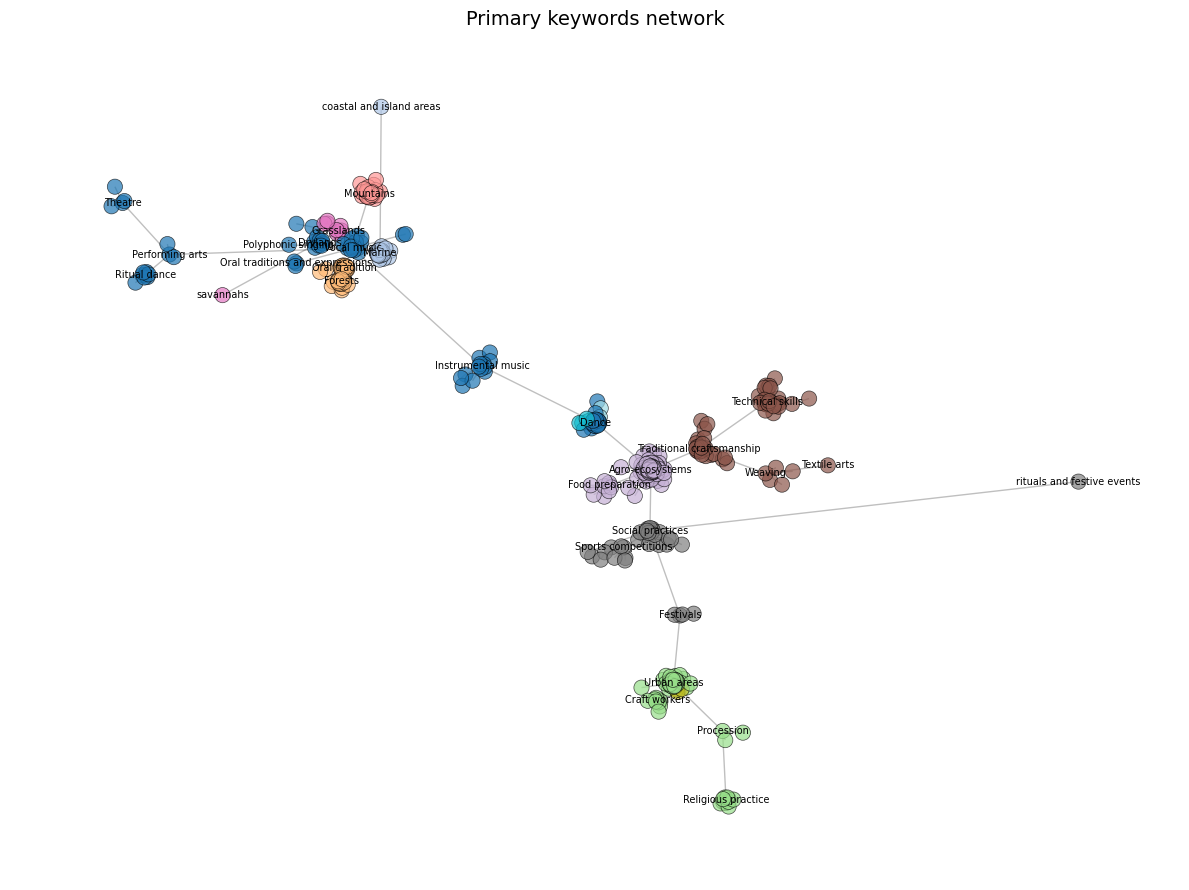

✔ Figure saved as secondary_keywords.png (600 dpi)


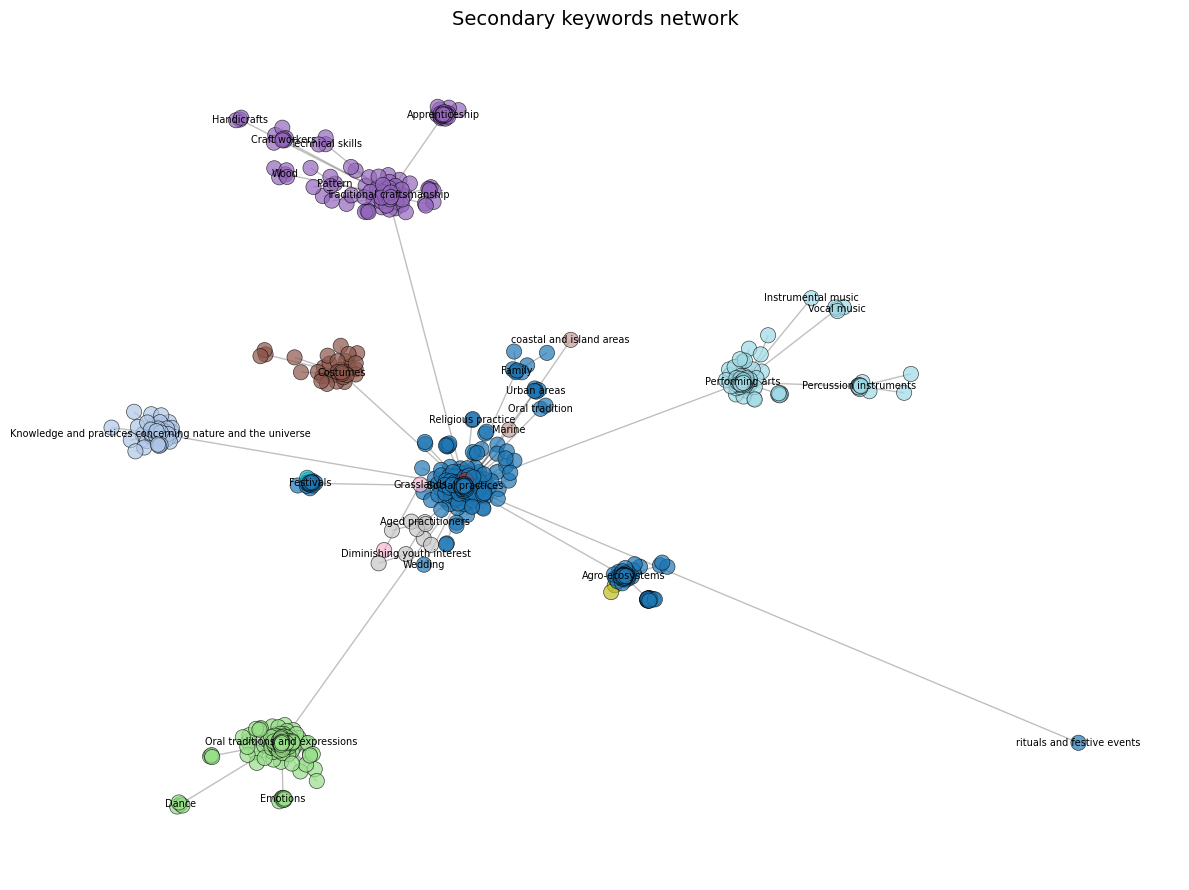

✔ Figure saved as cross_keywords.png (600 dpi)


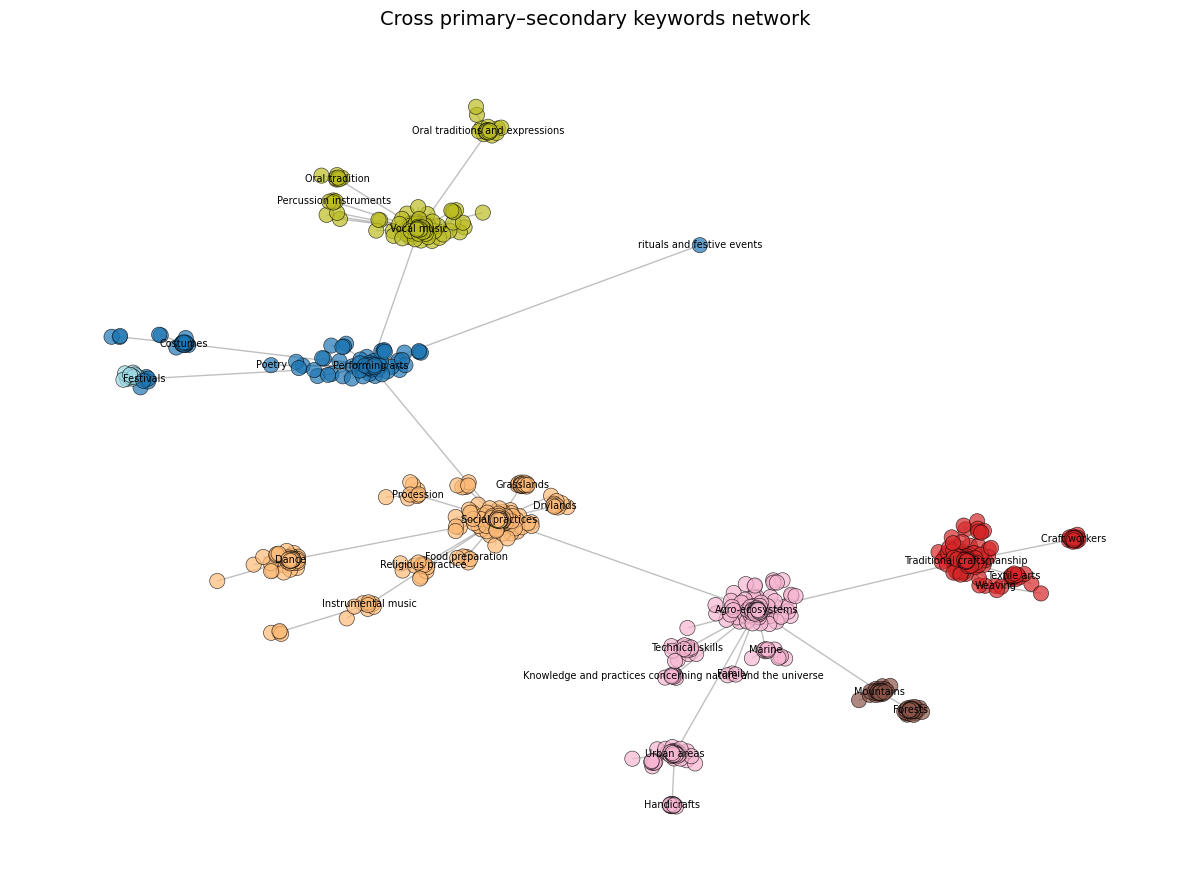

Red primaria: 454 nodos; 453 aristas
Red secundaria: 885 nodos; 884 aristas
Red cruzada: 944 nodos; 943 aristas
✔ Archivos exportados: summary_primary_communities.csv, summary_secondary_communities.csv


In [2]:
import pandas as pd
import re
import networkx as nx
from itertools import combinations
import community as community_louvain  # pip install python-louvain
import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns

# === 1. Cargar archivos ===
df_kw = pd.read_csv("keywords.csv", encoding="utf-8")
df_sites = pd.read_csv("sitios.csv", encoding="utf-8")

# === 2. Extraer ref_num desde keywords.csv ===
df_kw["ref_num"] = df_kw["link"].astype(str).str.extract(r'(\d+)(?!.*\d)', expand=False)

# === 3. Normalizar ref_num en sitios.csv ===
df_sites["ref_num"] = df_sites["Public ref. number"].astype(str).str.replace(r"\D+", "", regex=True)

# === 4. Merge (unión) ===
merged = df_kw.merge(df_sites, on="ref_num", how="left", suffixes=("_kw", "_sites"))

# === 5. Expandir bipartitas Elemento–Keyword ===
def expand_bipartite(df, keyword_col, eid_col="id"):
    rows = []
    for _, r in df.iterrows():
        kws = []
        if pd.notna(r.get(keyword_col, None)):
            kws = re.split(r";|,", str(r[keyword_col]))
            kws = [k.strip() for k in kws if k.strip()]
        for k in kws:
            rows.append({
                "element_id": r[eid_col],
                "keyword": k,
                "country": r.get("countries", None),  # ✅ usamos countries de keywords.csv
                "year": r.get("year", None),
                "list": r.get("list", None)
            })
    return pd.DataFrame(rows)

df_primary = expand_bipartite(merged, "primary_concepts")
df_secondary = expand_bipartite(merged, "secondary_concepts")

# === 6. Construcción de redes ===
def build_cooccurrence(df, col_kw="keyword", col_eid="element_id"):
    G = nx.Graph()
    for eid, group in df.groupby(col_eid):
        kws = group[col_kw].unique()
        for a, b in combinations(sorted(kws), 2):
            if G.has_edge(a, b):
                G[a][b]["weight"] += 1
                G[a][b]["elements"].append(eid)
            else:
                G.add_edge(a, b, weight=1, elements=[eid])
    return nx.maximum_spanning_tree(G)

G_primary = build_cooccurrence(df_primary)
G_secondary = build_cooccurrence(df_secondary)

# Red cruzada primaria–secundaria
G_cross = nx.Graph()
for eid in merged["id"]:
    prims = df_primary[df_primary["element_id"] == eid]["keyword"].tolist()
    secs  = df_secondary[df_secondary["element_id"] == eid]["keyword"].tolist()
    for p in prims:
        for s in secs:
            if G_cross.has_edge(p, s):
                G_cross[p][s]["weight"] += 1
                G_cross[p][s]["elements"].append(eid)
            else:
                G_cross.add_edge(p, s, weight=1, elements=[eid])

G_cross = nx.maximum_spanning_tree(G_cross)

# === 7. Comunidades con Louvain ===
def detect_communities(G):
    if G.number_of_nodes() == 0:
        return {}
    partition = community_louvain.best_partition(G, weight="weight")
    nx.set_node_attributes(G, partition, "community")
    return partition

partition_primary = detect_communities(G_primary)
partition_secondary = detect_communities(G_secondary)
partition_cross = detect_communities(G_cross)

# === 8. Resúmenes de comunidades ===
def summarize_communities(G, df_bip, col_kw="keyword"):
    comm_attr = nx.get_node_attributes(G, "community")
    rows = []
    for cid in set(comm_attr.values()):
        nodes = [n for n,c in comm_attr.items() if c==cid]
        sub = df_bip[df_bip[col_kw].isin(nodes)]
        rows.append({
            "community": cid,
            "n_keywords": len(nodes),
            "keywords_sample": ", ".join(nodes[:10]),
            "n_elements": sub["element_id"].nunique(),
            "countries": "; ".join(sub["country"].dropna().unique()[:10]),
            "years_range": f"{sub['year'].min()}–{sub['year'].max()}",
            "lists": "; ".join(sub["list"].dropna().unique())
        })
    return pd.DataFrame(rows)

summary_primary = summarize_communities(G_primary, df_primary)
summary_secondary = summarize_communities(G_secondary, df_secondary)

summary_primary.to_csv("summary_primary_communities.csv", index=False)
summary_secondary.to_csv("summary_secondary_communities.csv", index=False)

# === 9. Visualización de comunidades ===
def plot_communities(G, title="Keywords network", seed=42, n_labels=30, filename=None):
    if G.number_of_nodes() == 0:
        print("⚠️ Empty graph, nothing to display.")
        return
    
    communities = nx.get_node_attributes(G, "community")
    pos = nx.kamada_kawai_layout(G)
    colors = [communities[n] for n in G.nodes()]

    strength = dict(G.degree(weight="weight"))
    top_nodes = sorted(strength.items(), key=lambda x: x[1], reverse=True)[:n_labels]
    labels = {n: n for n, w in top_nodes}

    plt.figure(figsize=(12, 9))
    nx.draw_networkx_nodes(
        G, pos,
        node_size=120,
        node_color=colors,
        cmap=plt.cm.tab20,
        edgecolors="black",
        linewidths=0.5,
        alpha=0.7
    )
    nx.draw_networkx_edges(G, pos, alpha=0.25)
    nx.draw_networkx_labels(G, pos, labels, font_size=7, font_color="black")

    plt.title(title, fontsize=14)
    plt.axis("off")
    plt.tight_layout()

    if filename:
        plt.savefig(filename, dpi=600)
        print(f"✔ Figure saved as {filename} (600 dpi)")
    
    plt.show()

plot_communities(G_primary, "Primary keywords network", filename="primary_keywords.png")
plot_communities(G_secondary, "Secondary keywords network", filename="secondary_keywords.png")
plot_communities(G_cross, "Cross primary–secondary keywords network", filename="cross_keywords.png")

# === 10. Estadísticas finales ===
print("Red primaria:", G_primary.number_of_nodes(), "nodos;", G_primary.number_of_edges(), "aristas")
print("Red secundaria:", G_secondary.number_of_nodes(), "nodos;", G_secondary.number_of_edges(), "aristas")
print("Red cruzada:", G_cross.number_of_nodes(), "nodos;", G_cross.number_of_edges(), "aristas")

print("✔ Archivos exportados: summary_primary_communities.csv, summary_secondary_communities.csv")

In [5]:
import pandas as pd

# === Cargar los resultados ya exportados ===
summary_primary = pd.read_csv("summary_primary_communities.csv")
summary_secondary = pd.read_csv("summary_secondary_communities.csv")

# Mostrar nombres de columnas (solo para verificar)
print("Primary columns:", summary_primary.columns.tolist())
print("Secondary columns:", summary_secondary.columns.tolist())

# === Crear los diccionarios de etiquetas ===
labels_primary = dict(zip(summary_primary["community"], summary_primary["keywords_sample"]))
labels_secondary = dict(zip(summary_secondary["community"], summary_secondary["keywords_sample"]))

print(f"✔ labels_primary loaded: {len(labels_primary)} communities")
print(f"✔ labels_secondary loaded: {len(labels_secondary)} communities")


Primary columns: ['community', 'n_keywords', 'keywords_sample', 'n_elements', 'countries', 'years_range', 'lists']
Secondary columns: ['community', 'n_keywords', 'keywords_sample', 'n_elements', 'countries', 'years_range', 'lists']
✔ labels_primary loaded: 12 communities
✔ labels_secondary loaded: 13 communities


✔ Saved clean lineplot with guides: lineplot_primary_paper.png


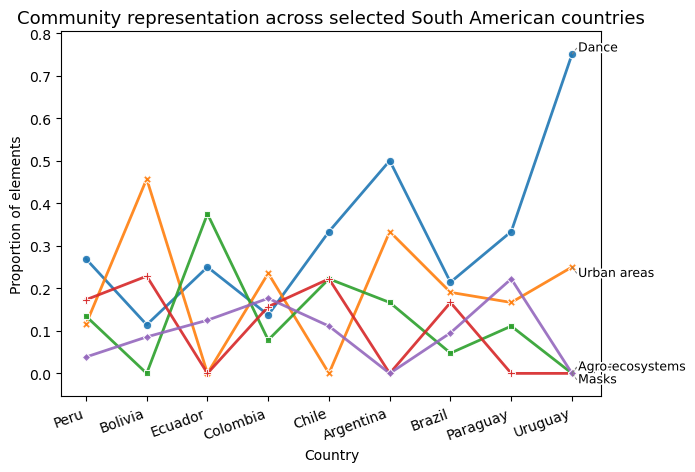

✔ Exported proportions_primary.csv
✔ Saved clean lineplot with guides: lineplot_secondary_paper.png


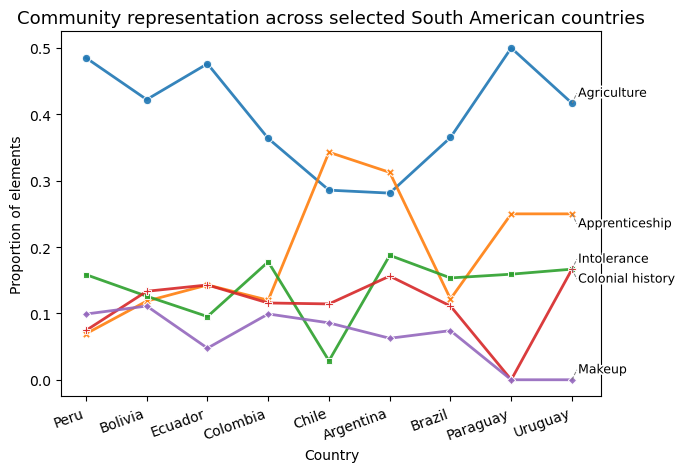

✔ Exported proportions_secondary.csv
✔ Saved barplot: barplot_primary_paper.png


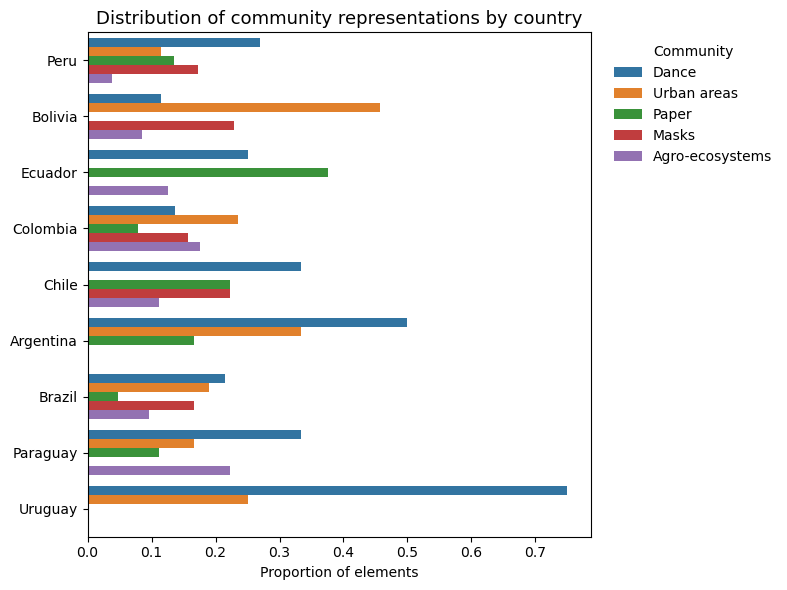

✔ Saved barplot: barplot_secondary_paper.png


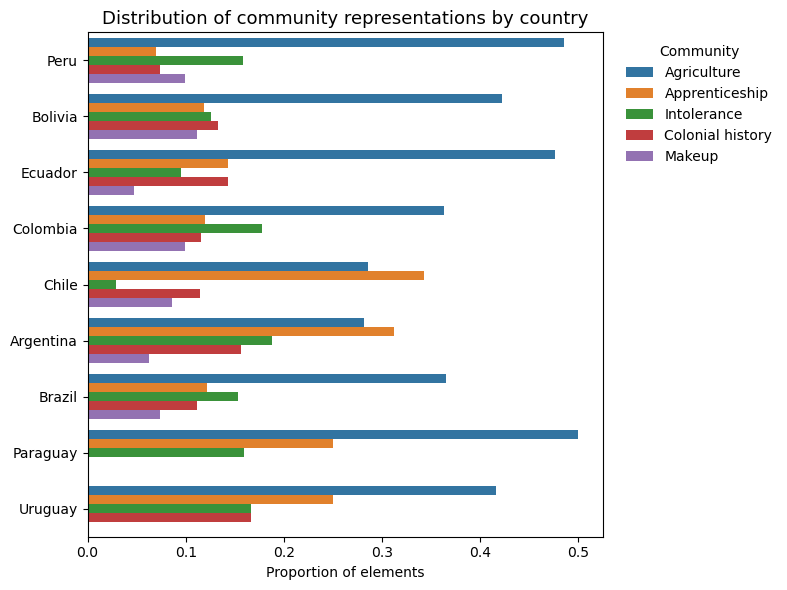

In [8]:
import matplotlib.patheffects as pe

def lineplot_direct_labels(df_bip, partition, labels, filename="lineplot_paper.png",
                           top_n=5, country_order=None):

    df = df_bip.copy()
    df["community"] = df["keyword"].map(partition)
    df = df.dropna(subset=["community","country"])

    # Filtrar solo países de interés
    focus_countries = ["Peru","Bolivia","Ecuador","Colombia","Chile","Argentina","Brazil","Paraguay","Uruguay"]
    df = df[df["country"].isin(focus_countries)]

    # Agregar proporciones país×comunidad
    pivot = pd.crosstab(df["country"], df["community"])
    pivot = pivot.div(pivot.sum(axis=1), axis=0).fillna(0)

    # Renombrar comunidades cortas
    labels_short = {cid: labels[cid].split(",")[0].capitalize() for cid in labels}
    pivot = pivot.rename(columns=labels_short)

    # Seleccionar top_n comunidades globales
    top_cols = pivot.sum().sort_values(ascending=False).head(top_n).index.tolist()
    pivot = pivot[top_cols]

    # Orden países
    if country_order is None:
        country_order = focus_countries
    pivot = pivot.loc[country_order]

    # Plot
    plt.figure(figsize=(8,5))
    ax = sns.lineplot(
        data=pivot,
        dashes=False,
        markers=True,
        alpha=0.9,
        linewidth=2
    )

    # 🚫 Eliminar la leyenda
    if ax.get_legend() is not None:
        ax.get_legend().remove()

    # Etiquetas al final de cada línea con guías punteadas
    x = pivot.shape[0]-1
    for i, comm in enumerate(top_cols):
        y = pivot.iloc[-1][comm]
        offset = (0.015 if i % 2 == 0 else -0.015)

        # Línea guía punteada
        ax.plot([x, x+0.08], [y, y+offset], color="gray", linestyle="--", linewidth=0.7)

        # Texto
        ax.text(
            x+0.1, y+offset, comm,
            ha="left", va="center", fontsize=9,
            path_effects=[pe.withStroke(linewidth=2.5, foreground="white")],
            clip_on=False
        )

    ax.set_title("Community representation across selected South American countries", fontsize=13)
    ax.set_ylabel("Proportion of elements")
    ax.set_xlabel("Country")
    plt.xticks(range(len(country_order)), country_order, rotation=20, ha="right")
    plt.subplots_adjust(right=0.8, bottom=0.15)
    plt.savefig(filename, dpi=600, bbox_inches="tight")
    print(f"✔ Saved clean lineplot with guides: {filename}")
    plt.show()

    return pivot

# === Normalización de países ===
country_map = {
    "Plurinational State of Bolivia": "Bolivia",
    "Estado Plurinacional de Bolivia": "Bolivia",
    "Bolivia (Plurinational State of)": "Bolivia",
    "Perú": "Peru",
    "Brazil": "Brazil",
    "Brasil": "Brazil",
    "Republic of Ecuador": "Ecuador",
    "Ecuador (Republic of)": "Ecuador",
    "Republic of Colombia": "Colombia",
    "Colombia (Republic of)": "Colombia",
    "Chile (Republic of)": "Chile"
}

df_primary["country"] = df_primary["country"].replace(country_map)
df_secondary["country"] = df_secondary["country"].replace(country_map)


# === Ejecutar para primarias y exportar CSV ===
pivot_primary = lineplot_direct_labels(
    df_primary, partition_primary, labels_primary,
    filename="lineplot_primary_paper.png", top_n=5
)
pivot_primary.to_csv("proportions_primary.csv")
print("✔ Exported proportions_primary.csv")

# === Ejecutar para secundarias y exportar CSV ===
pivot_secondary = lineplot_direct_labels(
    df_secondary, partition_secondary, labels_secondary,
    filename="lineplot_secondary_paper.png", top_n=5
)
pivot_secondary.to_csv("proportions_secondary.csv")
print("✔ Exported proportions_secondary.csv")

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def barplot_country_communities(pivot, filename="barplot_primary_paper.png"):
    """
    Visualiza las proporciones país×comunidad como barras horizontales.
    Usa el pivot ya generado en lineplot_direct_labels().
    """

    df_long = pivot.reset_index().melt(id_vars="country", var_name="community", value_name="proportion")

    plt.figure(figsize=(8,6))
    ax = sns.barplot(
        data=df_long,
        y="country",
        x="proportion",
        hue="community",
        orient="h",
        palette="tab10"
    )

    ax.set_title("Distribution of community representations by country", fontsize=13)
    ax.set_xlabel("Proportion of elements")
    ax.set_ylabel("")
    ax.legend(title="Community", bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
    plt.tight_layout()
    plt.savefig(filename, dpi=600, bbox_inches="tight")
    print(f"✔ Saved barplot: {filename}")
    plt.show()

# === Ejecutar con los resultados del gráfico anterior ===
barplot_country_communities(pivot_primary, filename="barplot_primary_paper.png")
barplot_country_communities(pivot_secondary, filename="barplot_secondary_paper.png")


✔ Saved entropy table: entropy_lines.csv
✔ Saved entropy line plot: entropy_lines.png


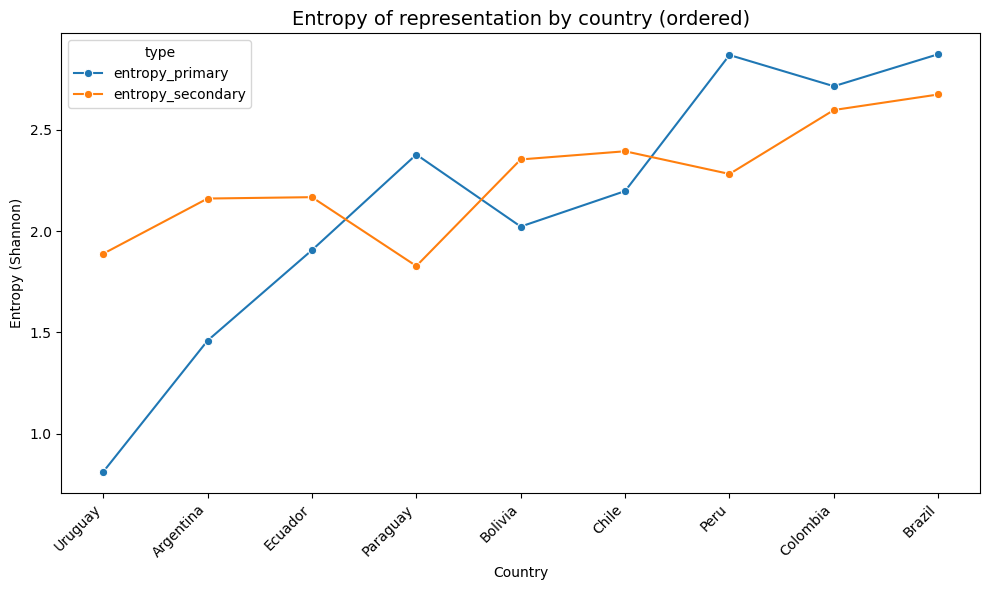

In [10]:
import numpy as np

# === 11. Función de entropía (Shannon) ===
def shannon_entropy(counts):
    total = sum(counts)
    if total == 0:
        return 0
    probs = [c/total for c in counts if c > 0]
    return -sum(p*np.log2(p) for p in probs)

# === 12. Cálculo de entropía por país ===
def entropy_by_country(df_bip, partition, countries_filter=None):
    df_bip = df_bip.copy()
    df_bip["community"] = df_bip["keyword"].map(partition)
    df_bip = df_bip.dropna(subset=["community","country"])
    if countries_filter:
        df_bip = df_bip[df_bip["country"].isin(countries_filter)]

    pivot = pd.crosstab(df_bip["country"], df_bip["community"])
    rows = []
    for country,row in pivot.iterrows():
        rows.append({"country":country,"entropy":shannon_entropy(row.tolist())})
    return pd.DataFrame(rows)

# === 13. Visualización en líneas (ordenado por entropía promedio) ===
def entropy_lineplot(df_entropy_primary, df_entropy_secondary, filename="entropy_lines.png", table_filename="entropy_lines.csv"):
    df_merge = pd.merge(df_entropy_primary, df_entropy_secondary, on="country", suffixes=("_primary","_secondary"))
    
    # Calcular entropía promedio y ordenar países
    df_merge["entropy_mean"] = df_merge[["entropy_primary","entropy_secondary"]].mean(axis=1)
    df_merge = df_merge.sort_values("entropy_mean", ascending=True)
    
    # Guardar tabla como CSV
    df_merge.to_csv(table_filename, index=False)
    print(f"✔ Saved entropy table: {table_filename}")
    
    df_plot = df_merge.melt(id_vars=["country","entropy_mean"], 
                            value_vars=["entropy_primary","entropy_secondary"],
                            var_name="type", value_name="entropy")

    plt.figure(figsize=(10,6))
    sns.lineplot(data=df_plot, x="country", y="entropy", hue="type", marker="o")
    
    plt.xticks(rotation=45, ha="right")
    plt.title("Entropy of representation by country (ordered)", fontsize=14)
    plt.xlabel("Country")
    plt.ylabel("Entropy (Shannon)")
    plt.tight_layout()
    plt.savefig(filename, dpi=600)
    print(f"✔ Saved entropy line plot: {filename}")
    plt.show()
    return df_merge, df_plot

# === 14. Ejecutar en Sudamérica ===
south_america = ["Peru","Bolivia","Ecuador","Colombia","Chile","Argentina","Brazil","Paraguay","Uruguay","Venezuela"]

df_entropy_primary = entropy_by_country(df_primary, partition_primary, south_america)
df_entropy_secondary = entropy_by_country(df_secondary, partition_secondary, south_america)

df_entropy_table, df_entropy_lines = entropy_lineplot(
    df_entropy_primary, df_entropy_secondary,
    filename="entropy_lines.png",
    table_filename="entropy_lines.csv"
)


In [ ]:
import seaborn as sns

# === 11. Asegurar columna de país ===
# Reinyectar columna de país en bipartitas
df_primary["country"] = df_primary["element_id"].map(
    merged.set_index("id")["States (EN)"]
)
df_secondary["country"] = df_secondary["element_id"].map(
    merged.set_index("id")["States (EN)"]
)

# === 12. Mapa de calor: comunidades × países ===
def heatmap_country_by_community(df_bip, partition, title, filename):
    df_bip = df_bip.copy()
    df_bip["community"] = df_bip["keyword"].map(partition)
    df_bip = df_bip.dropna(subset=["community", "country"])
    if df_bip.empty:
        print(f"⚠️ No hay datos para {title}, tabla vacía.")
        return pd.DataFrame()
    pivot = pd.crosstab(df_bip["community"], df_bip["country"])
    if pivot.empty:
        print(f"⚠️ Tabla vacía para {title}, no se genera heatmap.")
        return pivot
    plt.figure(figsize=(12,6))
    sns.heatmap(pivot, cmap="Blues", cbar_kws={'label': 'Count'})
    plt.title(title, fontsize=14)
    plt.ylabel("Community")
    plt.xlabel("Country")
    plt.tight_layout()
    plt.savefig(filename, dpi=600)
    print(f"✔ Saved heatmap: {filename}")
    plt.show()
    return pivot

pivot_primary = heatmap_country_by_community(
    df_primary, partition_primary,
    "Primary communities × countries",
    "heatmap_primary.png"
)
pivot_primary.to_csv("heatmap_primary_table.csv")

pivot_secondary = heatmap_country_by_community(
    df_secondary, partition_secondary,
    "Secondary communities × countries",
    "heatmap_secondary.png"
)
pivot_secondary.to_csv("heatmap_secondary_table.csv")

# === 13. Comparación primaria vs secundaria (conceptos críticos) ===
def compare_primary_secondary(df_primary, df_secondary, critical_terms, filename):
    rows = []
    for term in critical_terms:
        rows.append({
            "keyword": term,
            "primary_count": (df_primary["keyword"]==term).sum(),
            "secondary_count": (df_secondary["keyword"]==term).sum()
        })
    df_comp = pd.DataFrame(rows)
    df_comp_melt = df_comp.melt(id_vars="keyword", 
                                value_vars=["primary_count","secondary_count"],
                                var_name="position", value_name="count")
    plt.figure(figsize=(8,6))
    sns.barplot(data=df_comp_melt, x="keyword", y="count", hue="position")
    plt.title("Critical terms in Primary vs Secondary", fontsize=14)
    plt.ylabel("Frequency")
    plt.xlabel("Keyword")
    plt.tight_layout()
    plt.savefig(filename, dpi=600)
    print(f"✔ Saved comparison: {filename}")
    plt.show()
    return df_comp

critical_terms = ["Animismo", "Sincretismo religioso", "Tribu"]
df_comp = compare_primary_secondary(
    df_primary, df_secondary, critical_terms, "critical_terms.png"
)
df_comp.to_csv("critical_terms_table.csv", index=False)

# === 14. Red cruzada: top enlaces primaria–secundaria ===
def cross_network_top_links(df_primary, df_secondary, merged, top_n=20, filename="cross_links.png"):
    G_cross = nx.Graph()
    for eid in merged["id"]:
        prims = df_primary[df_primary["element_id"] == eid]["keyword"].tolist()
        secs  = df_secondary[df_secondary["element_id"] == eid]["keyword"].tolist()
        for p in prims:
            for s in secs:
                if G_cross.has_edge(p, s):
                    G_cross[p][s]["weight"] += 1
                else:
                    G_cross.add_edge(p, s, weight=1)
    # Seleccionar top enlaces por peso
    edges_sorted = sorted(G_cross.edges(data=True), key=lambda x: x[2]["weight"], reverse=True)[:top_n]
    H = nx.Graph()
    for u,v,d in edges_sorted:
        H.add_edge(u,v,weight=d["weight"])
    pos = nx.spring_layout(H, seed=42, k=0.5)
    weights = [H[u][v]["weight"] for u,v in H.edges()]
    plt.figure(figsize=(10,8))
    nx.draw_networkx_nodes(H, pos, node_size=500, node_color="lightblue", edgecolors="black")
    nx.draw_networkx_edges(H, pos, width=[w*0.3 for w in weights], alpha=0.6)
    nx.draw_networkx_labels(H, pos, font_size=9)
    plt.title(f"Top {top_n} Cross-links (Primary ↔ Secondary)", fontsize=14)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(filename, dpi=600)
    print(f"✔ Saved cross-links graph: {filename}")
    plt.show()
    return H

H = cross_network_top_links(df_primary, df_secondary, merged, top_n=20, filename="cross_links.png")
edges_data = [
    {"source": u, "target": v, "weight": d["weight"]}
    for u, v, d in H.edges(data=True)
]
pd.DataFrame(edges_data).to_csv("cross_links_table.csv", index=False)

print("✔ Tablas exportadas: heatmap_primary_table.csv, heatmap_secondary_table.csv, critical_terms_table.csv, cross_links_table.csv")
